In [15]:
import pandas as pd

chunk_iter = pd.read_csv(
    "pancreas_refseq_rpkms_wholeislet.txt",
    sep="\t",
    engine="python",
    chunksize=1000
)

total_genes = 0
num_samples = None

# First chunk
first_chunk = next(chunk_iter)
total_genes += first_chunk.shape[0]

# Debugging
print("Columns detected:")
print(first_chunk.columns.tolist())
print("Total columns:", len(first_chunk.columns))

# Count sample columns
# Here first column is GeneName index, second is RefSeqID,
# then 7 expression columns and 7 raw count columns
num_samples = (len(first_chunk.columns) - 1) 

# Remaining chunks
for chunk in chunk_iter:
    total_genes += chunk.shape[0]

print("Total Genes:", total_genes)
print("Total Samples:", num_samples)

Columns detected:
['#samples', 'HP1504101T2D_wholeislet', 'HP1506401_wholeislet', 'HP1504901_wholeislet', 'HP1508501T2D_wholeislet', 'HP1507101_wholeislet', 'HP1526901T2D_wholeislet', 'HP1525301T2D_wholeislet']
Total columns: 8
Total Genes: 26271
Total Samples: 7


In [16]:
first_chunk.head()

,,,,,,,,#samples,HP1504101T2D_wholeislet,HP1506401_wholeislet,HP1504901_wholeislet,HP1508501T2D_wholeislet,HP1507101_wholeislet,HP1526901T2D_wholeislet,HP1525301T2D_wholeislet
SGIP1,NM_032291,1.834634,2.903260,0.892323,2.049680,0.585871,1.480137,1.451944,360,616,204,567,171,270,268
AZIN2,NM_052998+NM_001293562,4.365918,3.596074,4.225489,3.266295,5.511107,5.014405,3.118402,388,344,434,405,729,410,259
CLIC4,NM_013943,19.848342,13.735953,19.221704,19.613011,11.755272,20.712484,16.357313,3679,2753,4151,5125,3241,3569,2852
AGBL4,NM_032785,0.944695,1.147623,1.436153,0.778012,1.555488,0.732015,0.859605,118,155,209,137,289,85,101
NECAP2,NM_001145277+NM_001145278+NM_018090,17.813955,18.669569,15.540075,22.586648,14.548781,23.008321,19.210497,1522,1737,1562,2754,1870,1826,1572


In [17]:
print(first_chunk.head()
     )

                                                                                                         #samples  \
SGIP1  NM_032291                           1.834634  2.903260  0.892323  2.049680  0.585871  1.480137    1.451944   
AZIN2  NM_052998+NM_001293562              4.365918  3.596074  4.225489  3.266295  5.511107  5.014405    3.118402   
CLIC4  NM_013943                           19.848342 13.735953 19.221704 19.613011 11.755272 20.712484  16.357313   
AGBL4  NM_032785                           0.944695  1.147623  1.436153  0.778012  1.555488  0.732015    0.859605   
NECAP2 NM_001145277+NM_001145278+NM_018090 17.813955 18.669569 15.540075 22.586648 14.548781 23.008321  19.210497   

                                                                                                        HP1504101T2D_wholeislet  \
SGIP1  NM_032291                           1.834634  2.903260  0.892323  2.049680  0.585871  1.480137                       360   
AZIN2  NM_052998+NM_001293562      

In [18]:
all_samples = first_chunk.columns[1:]  # ONLY skip '#samples'

disease_samples = [c for c in all_samples if "T2D" in c]
control_samples = [c for c in all_samples if "T2D" not in c]

print("Control samples:", len(control_samples))
print("Disease samples:", len(disease_samples))

Control samples: 3
Disease samples: 4


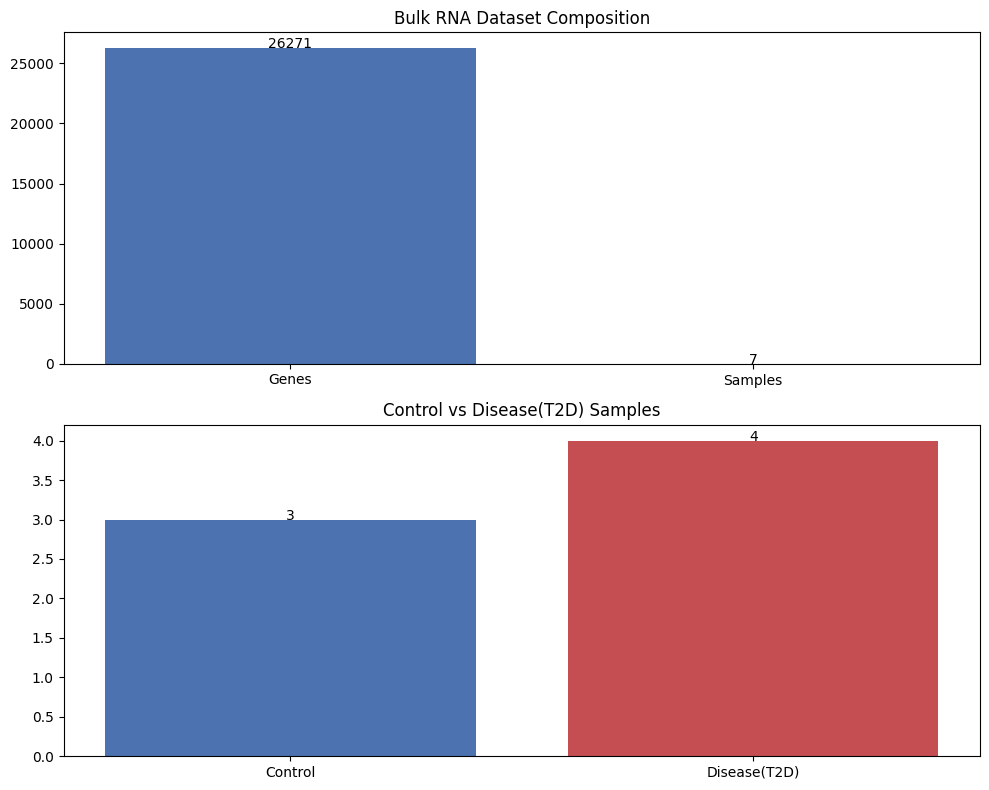

In [19]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Genes vs Samples
ax1.bar(["Genes", "Samples"], [total_genes, num_samples], color=['#4C72B0', '#55A868'])
for i, v in enumerate([total_genes, num_samples]):
    ax1.text(i, v, str(v), ha='center')

ax1.set_title("Bulk RNA Dataset Composition")

# Control vs Disease
ax2.bar(["Control", "Disease(T2D)"], [len(control_samples), len(disease_samples)],
        color=['#4C72B0', '#C44E52'])
for i, v in enumerate([len(control_samples), len(disease_samples)]):
    ax2.text(i, v, str(v), ha='center')

ax2.set_title("Control vs Disease(T2D) Samples")

plt.tight_layout()
plt.savefig("bulkRNA_summary.png", dpi=300)
plt.show()

In [20]:
print(first_chunk.columns.tolist())

['#samples', 'HP1504101T2D_wholeislet', 'HP1506401_wholeislet', 'HP1504901_wholeislet', 'HP1508501T2D_wholeislet', 'HP1507101_wholeislet', 'HP1526901T2D_wholeislet', 'HP1525301T2D_wholeislet']


In [21]:
# import pandas as pd

# # File paths
# input_file = "pancreas_refseq_rpkms_wholeislet.txt"
# control_file = "bulk_control_data.csv"
# disease_file = "bulk_disease_data.csv"

# # Read in chunks
# chunk_iter = pd.read_csv(input_file, sep="\t", chunksize=1000)

# # Get first chunk to identify columns
# first_chunk = next(chunk_iter)

# # Identify sample columns (skip '#samples')
# all_samples = first_chunk.columns[1:]

# # Split into control and disease
# disease_samples = [c for c in all_samples if "T2D" in c]
# control_samples = [c for c in all_samples if "T2D" not in c]

# # Include gene column
# control_columns = ['#samples'] + control_samples
# disease_columns = ['#samples'] + disease_samples

# # -----------------------------
# # Write first chunk
# # -----------------------------
# first_chunk[control_columns].to_csv(control_file, index=False, mode='w')
# first_chunk[disease_columns].to_csv(disease_file, index=False, mode='w')

# # -----------------------------
# # Process remaining chunks
# # -----------------------------
# for chunk in chunk_iter:
#     chunk[control_columns].to_csv(control_file, index=False, mode='a', header=False)
#     chunk[disease_columns].to_csv(disease_file, index=False, mode='a', header=False)

# print("✅ Control data saved:", control_file)
# print("✅ Disease data saved:", disease_file)


In [22]:
import pandas as pd

# Read in chunks
control_chunks = pd.read_csv("bulk_control_data.csv", chunksize=1000)
disease_chunks = pd.read_csv("bulk_disease_data.csv", chunksize=1000)

# Get first chunk
control_first = next(control_chunks)
disease_first = next(disease_chunks)

print("Control Data Sample:")
control_first.head()



Control Data Sample:


,#samples,HP1506401_wholeislet,HP1504901_wholeislet,HP1507101_wholeislet
0,1.451944,616,204,171
1,3.118402,344,434,729
2,16.357313,2753,4151,3241
3,0.859605,155,209,289
4,19.210497,1737,1562,1870


In [23]:
print("\nDisease Data Sample:")
disease_first.head()


Disease Data Sample:


,#samples,HP1504101T2D_wholeislet,HP1508501T2D_wholeislet,HP1526901T2D_wholeislet,HP1525301T2D_wholeislet
0,1.451944,360,567,270,268
1,3.118402,388,405,410,259
2,16.357313,3679,5125,3569,2852
3,0.859605,118,137,85,101
4,19.210497,1522,2754,1826,1572


In [24]:
# Control counts
control_rows = 0
control_cols = None

for chunk in pd.read_csv("bulk_control_data.csv", chunksize=1000):
    control_rows += chunk.shape[0]
    if control_cols is None:
        control_cols = chunk.shape[1] - 1  # exclude '#samples'

print("Control Genes:", control_rows)
print("Control Samples:", control_cols)

# Disease counts
disease_rows = 0
disease_cols = None

for chunk in pd.read_csv("bulk_disease_data.csv", chunksize=1000):
    disease_rows += chunk.shape[0]
    if disease_cols is None:
        disease_cols = chunk.shape[1] - 1

print("Disease Genes:", disease_rows)
print("Disease Samples:", disease_cols)

Control Genes: 26271
Control Samples: 3
Disease Genes: 26271
Disease Samples: 4
